In [29]:
import os
import pickle
import numpy as np
np.random.seed(42)
import pandas as pd
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from scipy.special import softmax

In [34]:
dataset = "steam"
sim_metric = "cos"
topk = 18
mode = "_qwen_mean"
emb_mode = "llm"
model = "llmesr_mean_sasrec"
ts_user = 16
ts_item = 69
item_num = 4722

### Get the topk similar user

In [35]:
# load the llm user embedding
user_llm_emb = pickle.load(open(os.path.join(dataset+"/handled/", f"usr_emb_np{mode}.pkl"), "rb")) # user_llm_emb.shape = (23310, 3584)
# user_collab_emb = pickle.load(open(os.path.join("/home/lgr/LLM-ESR/saved/", dataset, model,"usr_emb_bert4rec.pkl"), "rb")) # user_collab_emb.shape = (23310, 128)
# origin_user_emb = pickle.load(open(os.path.join(dataset+"/handled/", f"usr_emb_np.pkl"), "rb"))


In [36]:
user_llm_emb.shape

(23310, 3584)

In [37]:
# calculate the similarity score between users based on llm user embedding
if emb_mode == "llm":
    print("采用llm 的emb做相似度检索")
    user_emb = user_llm_emb
# else:
#     print("采用esr encoder 的emb做相似度检索")
#     user_emb = user_collab_emb
if sim_metric == "sin":
    score_matrix = np.dot(user_emb, user_emb.T)
elif sim_metric == "cos":
    score_matrix = cosine_similarity(user_emb, user_emb)

采用llm 的emb做相似度检索


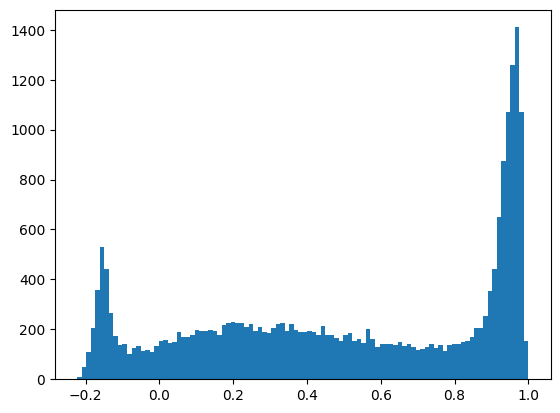

In [6]:
plt.hist(score_matrix[9234], bins=100)
plt.show()

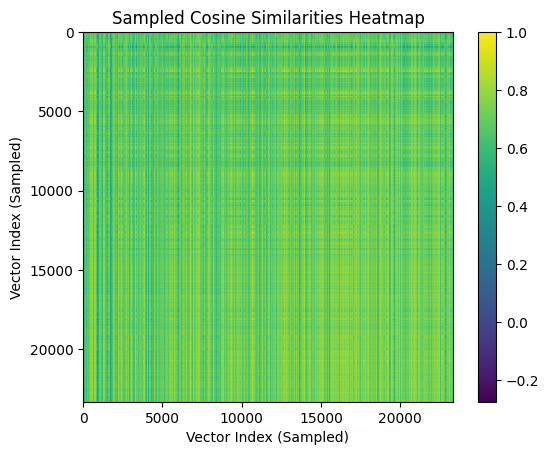

In [41]:
# 绘制热力图
plt.imshow(score_matrix, cmap='viridis')  # 使用viridis颜色映射，可根据喜好换其他如'coolwarm'等
plt.colorbar()  # 显示颜色条，方便查看相似度对应的颜色
plt.title("Sampled Cosine Similarities Heatmap")
plt.xlabel("Vector Index (Sampled)")
plt.ylabel("Vector Index (Sampled)")
plt.show()

In [38]:
rank_matrix = np.argsort(-score_matrix, axis=-1)    # user id starts from 0

In [39]:
rank_matrix[:, :]  # 第一行表示。 用户0最相似的用户是0自己，然后是239，800

array([[    0,  9562,   302, ...,    35, 11227,  1433],
       [    1,  6827,  1220, ...,    35, 11227,  1433],
       [    2,  6844,  8120, ...,    35, 11227,  1433],
       ...,
       [23307,  6900, 16894, ..., 16842,  1980,  8481],
       [23308, 11455, 18142, ..., 12607,  8481, 11615],
       [23309, 10458,  2272, ...,  1980,  8481,  1115]])

In [40]:
final_rank_matrix = rank_matrix[:, 1:]  #每一行中，第一个值（rank_matrix[:, 0]）是用户自己的索引，因为相似度最高的永远是自身
final_rank_matrix = final_rank_matrix[:, :topk] #从原始的 rank_matrix 中剔除自身相似度的影响，并保留与当前用户相似度最高的 topk 个用户

In [23]:
final_rank_matrix[0]

array([ 9562,   302,  4720, 13218,  3790, 11589,  4686,  7512,  4628,
        9781,  6423,  8451,   305,   695, 11657,  8423,  8524, 10520,
       17414,  4966,  6011, 17541, 10066,  3459,  1704,  1763, 10732,
        4520, 18060,  4455, 10307,  5106,  6020,    18, 10362,  1555,
       13654,  1804,  9979,  1499, 13913,  4293,  4124,   665,  7947,
       15129, 15881,  6613,   963,  6867, 13249,  2860,  1076,  3073,
        4305,  1627,   953, 14936,  8176,  2897, 12846,  6583,  9332,
        4521,  7386,  3226,   479, 17059,   890,  1989,  2338,  7878,
        1849,  4435,  4033,   135,   488,  9481,  8411,  5083, 10145,
       15472,  8521,  2228, 14291,  3066,  1318,  5905, 16970,  8535,
        1074,  8475, 15010,  4947,   438,  3703,  1035, 16783,  7601,
       10849])

#### 保存所有用户与其Top 100相似用户的相似度的值

In [33]:
row_indices = np.arange(final_rank_matrix.shape[0]).reshape(-1, 1)  # shape: (23310, 1)

# 使用高级索引提取每个用户与top-100用户的相似度
top_100_similarities = score_matrix[row_indices, final_rank_matrix]

In [34]:
top_100_similarities.shape

(52204, 100)

In [35]:
top_100_similarities[-1]

array([0.97570988, 0.97332726, 0.97049415, 0.9704112 , 0.97002623,
       0.96967209, 0.96853986, 0.96823731, 0.96803403, 0.96676387,
       0.96649332, 0.96640903, 0.96575042, 0.96542412, 0.96541338,
       0.9653275 , 0.96514742, 0.96514357, 0.96465536, 0.96418462,
       0.96413334, 0.96387428, 0.9635346 , 0.96348047, 0.96326963,
       0.96323354, 0.96319804, 0.96299884, 0.96273849, 0.96255679,
       0.96232194, 0.96225498, 0.96220476, 0.96218545, 0.96214216,
       0.96188073, 0.96180064, 0.96177884, 0.96176258, 0.96174858,
       0.96141239, 0.96140022, 0.96137329, 0.96135253, 0.96128143,
       0.96111719, 0.960957  , 0.96070648, 0.96043842, 0.96017142,
       0.95988639, 0.95982459, 0.95973035, 0.95961424, 0.95950813,
       0.95933062, 0.95914216, 0.959126  , 0.95907193, 0.95903331,
       0.95900432, 0.9589679 , 0.95867943, 0.95853963, 0.95853937,
       0.95851295, 0.95849253, 0.95840481, 0.95838268, 0.95833088,
       0.95832268, 0.95828031, 0.95814454, 0.9581218 , 0.95810

In [36]:
## Save llm embedding based similar users
pickle.dump(top_100_similarities, open(os.path.join(dataset+"/handled/", f"sim_user_score_100{mode}_{emb_mode}.pkl"), "wb"))

In [79]:
softmax_scores = softmax(top_100_similarities, axis=1)

print(softmax_scores.shape)  # 输出: (23310, 100)
print(np.sum(softmax_scores[0]))  # 验证第一行的和是否接近1.0

(23310, 100)
1.0000001


In [25]:
softmax_scores

array([[0.01006409, 0.01005338, 0.010048  , ..., 0.00997423, 0.00997392,
        0.00997381],
       [0.01006358, 0.01005126, 0.01004873, ..., 0.00997162, 0.00997131,
        0.00997029],
       [0.01006436, 0.01006185, 0.01005937, ..., 0.00997457, 0.00997435,
        0.00997416],
       ...,
       [0.01020794, 0.01012817, 0.01012289, ..., 0.0099348 , 0.00993464,
        0.0099344 ],
       [0.01005951, 0.01005278, 0.01005275, ..., 0.00998164, 0.00998112,
        0.00998065],
       [0.01010932, 0.0100966 , 0.01006964, ..., 0.00996464, 0.00996264,
        0.0099625 ]], dtype=float32)

### Get the sequence length of each user

In [41]:
User = defaultdict(list)
seq_len = []
usernum, itemnum = 0, 0
f = open('./%s/handled/%s.txt' % (dataset, "inter"), 'r')
for line in f:  # use a dict to save all seqeuces of each user
    u, i = line.rstrip().split(' ')
    u = int(u)
    i = int(i)
    usernum = max(u, usernum)
    itemnum = max(i, itemnum)
    User[u].append(i)

for user, seq in User.items():
    seq_len.append(len(seq))

In [42]:
long_sim_user_len = []
short_sim_user_len = []
sim_user_len = []
for i, sim_user_list in enumerate(final_rank_matrix):
    avg_len = 0
    for sim_user in sim_user_list[:18]:
        avg_len += seq_len[sim_user] / 18
    if seq_len[i] > ts_user:
        long_sim_user_len.append(avg_len)
    else:
        short_sim_user_len.append(avg_len)
    sim_user_len.append(avg_len)
print("Long User avg similar user len:", np.mean(long_sim_user_len))
print("short User avg similar user len:", np.mean(short_sim_user_len))
print("All User avg similar user len:", np.mean(sim_user_len))

Long User avg similar user len: 31.360581832673294
short User avg similar user len: 9.426356246426275
All User avg similar user len: 13.624064540731208


### Select the similar user

In [85]:
final_rank_matrix

array([[10544, 18753,  1839, ...,  5891, 12682,   313],
       [ 2445, 18966, 12756, ...,  5121, 14964, 19510],
       [22257,  5041,  3103, ...,  1142, 11874, 18136],
       ...,
       [13454, 12554, 23256, ..., 19477, 14857, 14887],
       [11407,  7928,  4885, ..., 15739,  4217, 21549],
       [ 7650,   706, 21617, ..., 12554, 13039,  2197]])

In [14]:
## Save llm embedding based similar users
pickle.dump(final_rank_matrix, open(os.path.join(dataset+"/handled/", f"sim_user_100{mode}_{emb_mode}.pkl"), "wb"))

In [52]:
final_rank_matrix.shape

(23310, 18)

#### 基于启发式方法进行过滤

In [12]:
import math
from tqdm import tqdm
from collections import defaultdict

class ItemVectorSimilarity:
    def __init__(self, user_item_dict):
        """初始化物品向量相似度计算器"""
        # 构建物品ID到索引的映射
        self.item_to_index = {}
        self.index_to_item = []
        self._build_item_index(user_item_dict)
        
        # 预计算用户向量（可选，用于优化性能）
        self.user_vectors = self._build_user_vectors(user_item_dict)
        
    def _build_item_index(self, user_item_dict):
        """构建物品ID到索引的映射"""
        all_items = set()
        for items in user_item_dict.values():
            all_items.update(items)
        
        self.index_to_item = list(all_items)
        self.item_to_index = {item: idx for idx, item in enumerate(self.index_to_item)}
        print("物品总数为：",len(self.index_to_item))

    def _build_user_vectors(self, user_item_dict):
        """构建用户向量（独热编码）"""
        user_vectors = {}
        for user_id, items in user_item_dict.items():
            vector = self.items_to_vector(items)
            user_vectors[user_id] = vector
        return user_vectors
        
    def items_to_vector(self, items):
        """将物品列表转换为独热编码向量"""
        vector = [0] * item_num
        for item in items:
            # if item in self.item_to_index:
            vector[self.item_to_index[item]] = 1
        return vector
    
    def cosine_similarity(self, vec1, vec2):
        """计算余弦相似度"""
        dot_product = sum(a * b for a, b in zip(vec1, vec2))
        norm_a = math.sqrt(sum(a**2 for a in vec1))
        norm_b = math.sqrt(sum(b**2 for b in vec2))
        if norm_a == 0 or norm_b == 0:
            return 0
        return dot_product / (norm_a * norm_b)

    def cosine_similarity_group(self, vec, vec_list):
        """计算单个向量与向量列表中所有向量的余弦相似度"""
        # 转换为NumPy数组
        vec = np.array(vec)
        vec_list = np.array(vec_list)
        
        # 预计算输入向量的范数
        vec_norm = np.linalg.norm(vec)
        if vec_norm == 0:
            return [0] * len(vec_list)
        
        # 向量化计算所有点积
        dot_products = np.dot(vec_list, vec)
        
        # 预计算向量列表中所有向量的范数
        vec_list_norms = np.linalg.norm(vec_list, axis=1)
        
        # 处理零范数的情况
        mask = vec_list_norms == 0
        vec_list_norms[mask] = 1  # 避免除以零，这些将被设置为0
        
        # 计算余弦相似度
        similarities = dot_products / (vec_norm * vec_list_norms)
        
        # 设置零范数向量的相似度为0
        similarities[mask] = 0
        
        return similarities.tolist()

    def jaccard_similarity(self, vec1, vec2):
        """计算Jaccard相似度"""
        intersection = sum(1 for a, b in zip(vec1, vec2) if a == b == 1)
        union = sum(1 for a, b in zip(vec1, vec2) if a == 1 or b == 1)
        if union == 0:
            return 0
        return intersection / union
    
    def calculate_similarity(self, user1_id, user2_id, method="cosine"):
        """计算两个用户的相似度"""
        if user1_id not in self.user_vectors or user2_id not in self.user_vectors:
            raise ValueError(f"用户ID {user1_id} 或 {user2_id} 不存在")
        
        vec1 = self.user_vectors[user1_id]
        vec2 = self.user_vectors[user2_id]
        
        if method == "cosine":
            return self.cosine_similarity(vec1, vec2)
        elif method == "jaccard":
            return self.jaccard_similarity(vec1, vec2)
        else:
            raise ValueError(f"不支持的相似度计算方法: {method}")
        
    def calculate_similarity_group(self, user1_id, user_id_list, method="cosine"):
        """计算两个用户的相似度"""
        if user1_id not in self.user_vectors:
            raise ValueError(f"用户ID {user1_id}不存在")
        
        vec1 = self.user_vectors[user1_id]
        vec_list = [self.user_vectors.get(user_id) for user_id in user_id_list]
        
        if method == "cosine":
            return self.cosine_similarity_group(vec1, vec_list)
        else:
            raise ValueError(f"不支持的相似度计算方法: {method}")
        
    def pearson_correlation(self, target_user_id, similar_user_ids):
        """
        计算目标用户向量与多个相似用户向量之间的皮尔逊相关系数。

        参数:
        target_user_vector (numpy.ndarray): 目标用户向量，一维数组形式
        similar_users_vectors (numpy.ndarray): 多个相似用户向量组成的二维数组，每一行代表一个相似用户的向量

        返回:
        numpy.ndarray: 包含目标用户与每个相似用户之间皮尔逊相关系数的一维数组
        """
        vec1 = self.user_vectors[target_user_id]
        vec_list = [self.user_vectors.get(user_id) for user_id in similar_user_ids]

        target_user_vector = np.array(vec1)
        similar_users_vectors = np.array(vec_list)
        concat_vector = np.concatenate([target_user_vector.reshape(1, -1), similar_users_vectors], axis=0)
        correlation_coefficients = np.corrcoef(concat_vector)

        return correlation_coefficients[0,1:]


# 示例用法
if __name__ == "__main__":
    # 示例用户-物品交互数据
    user_item_dict = User

    
    # 初始化相似度计算器
    similarity_calculator = ItemVectorSimilarity(user_item_dict)
    
    sim_scores = []
    # TODO 这里不同数据集的起始用户索引不一样，有的是0，有的是1
    for i in tqdm(range(1,final_rank_matrix.shape[0])):
        sim12 = similarity_calculator.pearson_correlation(i, final_rank_matrix[i])
        sim_scores.append(sim12)


物品总数为： 4722


  0%|          | 26/9093 [00:00<02:24, 62.85it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (18,) + inhomogeneous part.

In [51]:
similarity_calculator = ItemVectorSimilarity(user_item_dict)

物品总数为： 57289


In [62]:
sim12 = similarity_calculator.pearson_correlation(2477, final_rank_matrix[2477])

In [43]:
import math
import numpy as np
from tqdm import tqdm
from collections import defaultdict

class ItemVectorSimilarity:
    def __init__(self, user_item_dict):
        """初始化物品向量相似度计算器"""
        # 构建物品ID到索引的映射
        self.item_to_index = {}
        self.index_to_item = []
        self._build_item_index(user_item_dict)
        
        # 物品数量，用于构建向量
        self.item_num = len(self.index_to_item)
        
        # 预计算用户向量
        self.user_vectors = self._build_user_vectors(user_item_dict)
        
        # 有效用户ID集合
        self.valid_user_ids = set(self.user_vectors.keys())
        
    def _build_item_index(self, user_item_dict):
        """构建物品ID到索引的映射"""
        all_items = set()
        for items in user_item_dict.values():
            all_items.update(items)
        
        self.index_to_item = list(all_items)
        self.item_to_index = {item: idx for idx, item in enumerate(self.index_to_item)}
        print("物品总数为：", len(self.index_to_item))

    def _build_user_vectors(self, user_item_dict):
        """构建用户向量（独热编码）"""
        user_vectors = {}
        for user_id, items in user_item_dict.items():
            vector = self.items_to_vector(items)
            user_vectors[user_id] = vector
        return user_vectors
        
    def items_to_vector(self, items):
        """将物品列表转换为独热编码向量"""
        vector = [0] * self.item_num
        for item in items:
            if item in self.item_to_index:
                vector[self.item_to_index[item]] = 1
        return vector
    
    def cosine_similarity(self, vec1, vec2):
        """计算余弦相似度"""
        dot_product = sum(a * b for a, b in zip(vec1, vec2))
        norm_a = math.sqrt(sum(a**2 for a in vec1))
        norm_b = math.sqrt(sum(b**2 for b in vec2))
        if norm_a == 0 or norm_b == 0:
            return 0
        return dot_product / (norm_a * norm_b)

    def cosine_similarity_group(self, vec, vec_list):
        """计算单个向量与向量列表中所有向量的余弦相似度"""
        # 转换为NumPy数组
        vec = np.array(vec)
        vec_list = np.array(vec_list)
        
        # 预计算输入向量的范数
        vec_norm = np.linalg.norm(vec)
        if vec_norm == 0:
            return [0] * len(vec_list)
        
        # 向量化计算所有点积
        dot_products = np.dot(vec_list, vec)
        
        # 预计算向量列表中所有向量的范数
        vec_list_norms = np.linalg.norm(vec_list, axis=1)
        
        # 处理零范数的情况
        mask = vec_list_norms == 0
        vec_list_norms[mask] = 1  # 避免除以零，这些将被设置为0
        
        # 计算余弦相似度
        similarities = dot_products / (vec_norm * vec_list_norms)
        
        # 设置零范数向量的相似度为0
        similarities[mask] = 0
        
        return similarities.tolist()

    def jaccard_similarity(self, vec1, vec2):
        """计算Jaccard相似度"""
        intersection = sum(1 for a, b in zip(vec1, vec2) if a == b == 1)
        union = sum(1 for a, b in zip(vec1, vec2) if a == 1 or b == 1)
        if union == 0:
            return 0
        return intersection / union
    
    def jaccard_similarity_group(self, vec, vec_list):
        """计算单个向量与向量列表中所有向量的杰卡德相似度"""
        # 转换为NumPy数组以便高效计算
        vec = np.array(vec, dtype=bool)
        vec_list = np.array(vec_list, dtype=bool)
        
        # 计算每个向量与目标向量的交集和并集
        intersections = np.logical_and(vec_list, vec).sum(axis=1)
        unions = np.logical_or(vec_list, vec).sum(axis=1)
        
        # 处理并集为0的情况（避免除零错误）
        jaccard_scores = np.divide(
            intersections, 
            unions, 
            out=np.zeros_like(intersections, dtype=float), 
            where=unions != 0
        )
        
        return jaccard_scores.tolist()
    
    def calculate_similarity(self, user1_id, user2_id, method="cosine"):
        """计算两个用户的相似度"""
        if user1_id not in self.user_vectors or user2_id not in self.user_vectors:
            raise ValueError(f"用户ID {user1_id} 或 {user2_id} 不存在")
        
        vec1 = self.user_vectors[user1_id]
        vec2 = self.user_vectors[user2_id]
        
        if method == "cosine":
            return self.cosine_similarity(vec1, vec2)
        elif method == "jaccard":
            return self.jaccard_similarity(vec1, vec2)
        else:
            raise ValueError(f"不支持的相似度计算方法: {method}")
        
    def calculate_similarity_group(self, user1_id, user_id_list, method="cosine"):
        """计算目标用户与多个用户的相似度，支持cosine和jaccard方法"""
        if user1_id not in self.user_vectors:
            raise ValueError(f"用户ID {user1_id}不存在")
        
        # 过滤掉不存在的用户ID
        valid_user_ids = [user_id for user_id in user_id_list if user_id in self.user_vectors]
        
        if not valid_user_ids:
            return [0] * len(user_id_list)
        
        vec1 = self.user_vectors[user1_id]
        vec_list = [self.user_vectors[user_id] for user_id in valid_user_ids]
        
        # 构建结果映射，不存在的用户ID对应的相似度为0
        similarity_map = {}
        if method == "cosine":
            similarities = self.cosine_similarity_group(vec1, vec_list)
            similarity_map = {user_id: sim for user_id, sim in zip(valid_user_ids, similarities)}
        elif method == "jaccard":
            similarities = self.jaccard_similarity_group(vec1, vec_list)
            similarity_map = {user_id: sim for user_id, sim in zip(valid_user_ids, similarities)}
        else:
            raise ValueError(f"不支持的相似度计算方法: {method}")
        
        # 按原始顺序返回相似度得分
        return [similarity_map.get(user_id, 0) for user_id in user_id_list]

    def pearson_correlation(self, target_user_id, similar_user_ids):
        """
        计算目标用户向量与多个相似用户向量之间的皮尔逊相关系数。
        处理了相似用户ID不存在的情况，确保向量维度一致。
        """
        if target_user_id not in self.user_vectors:
            raise ValueError(f"目标用户ID {target_user_id} 不存在")
        
        # 过滤掉不存在的相似用户ID
        valid_similar_user_ids = [user_id for user_id in similar_user_ids 
                                  if user_id in self.user_vectors]
        
        if not valid_similar_user_ids:
            # 如果没有有效的相似用户，返回全零数组
            return np.zeros(len(similar_user_ids))
        
        # 获取目标用户向量和有效相似用户向量
        target_vector = np.array(self.user_vectors[target_user_id])
        similar_vectors = np.array([self.user_vectors[user_id] 
                                    for user_id in valid_similar_user_ids])
        
        # 计算皮尔逊相关系数
        if len(valid_similar_user_ids) == 1:
            # 处理只有一个相似用户的情况
            similar_vector = similar_vectors[0]
            if np.var(target_vector) == 0 or np.var(similar_vector) == 0:
                return np.array([0.0])
            correlation = np.corrcoef(target_vector, similar_vector)[0, 1]
            correlations = np.array([correlation])
        else:
            # 多个相似用户的情况
            all_vectors = np.vstack([target_vector, similar_vectors])
            correlation_matrix = np.corrcoef(all_vectors)
            correlations = correlation_matrix[0, 1:]
        
        # 构建结果映射，不存在的用户ID对应的相似度为0
        correlation_map = {user_id: corr for user_id, corr 
                          in zip(valid_similar_user_ids, correlations)}
        
        # 按原始顺序返回相似度得分
        return np.array([correlation_map.get(user_id, 0.0) 
                        for user_id in similar_user_ids])

# 示例用法
if __name__ == "__main__":
    # 示例用户-物品交互数据
    user_item_dict = User
    
    # 初始化相似度计算器
    similarity_calculator = ItemVectorSimilarity(user_item_dict)
    
    # 计算所有用户与其相似用户的皮尔逊相关系数
    sim_scores = []
    # 注意：这里假设final_rank_matrix的行索引与user_item_dict的用户ID一致
    # 如果不一致，需要进行相应的映射转换
    for i in tqdm(range(final_rank_matrix.shape[0])):
        # 获取当前用户ID（假设为i+1，根据实际情况调整）
        # user_id = i + 1
        user_id = i + 1
        # 获取该用户的相似用户列表
        similar_users = final_rank_matrix[i]
        # 计算皮尔逊相关系数
        sim = similarity_calculator.pearson_correlation(user_id, similar_users)
        # sim = similarity_calculator.calculate_similarity_group(user_id, similar_users, method="jaccard")
        sim_scores.append(sim)
    
    # 转换为NumPy数组以便更好地查看形状
    sim_scores = np.array(sim_scores)
    print("相似度计算结果形状:", sim_scores.shape)
    print("相似度计算结果:", sim_scores)

物品总数为： 5237


100%|██████████| 23310/23310 [02:55<00:00, 133.13it/s]

相似度计算结果形状: (23310, 18)
相似度计算结果: [[ 0.03977641  0.04898323 -0.00410134 ...  0.07080143  0.02392295
  -0.00620598]
 [-0.00270819 -0.00342758 -0.00437352 ...  0.05461018 -0.00462028
  -0.00392867]
 [ 0.03321646  0.14796797  0.02969402 ...  0.02686038 -0.00305079
   0.15795806]
 ...
 [-0.0032994  -0.00162289 -0.00202507 ... -0.00202507 -0.0013247
  -0.00171084]
 [-0.00193274 -0.00187485 -0.0015538  ... -0.00168948 -0.00114701
  -0.0015538 ]
 [-0.00135215 -0.00181479 -0.00135215 ... -0.00378868  0.10378602
  -0.00191314]]


In [26]:
counts = []
count = 0
for i in range(len(sim_scores)):
    for j in sim_scores[i][:]:
        if j > -1:
            count += 1
    counts.append(count)
    count = 0
print("平均相似用户个数为:",np.mean(counts))

平均相似用户个数为: 100.0


In [22]:
sim_scores[0]

array([0.01388889, 0.02409639, 0.        , 0.        , 0.        ,
       0.025     , 0.02409639, 0.01098901, 0.        , 0.01388889,
       0.        , 0.        , 0.01162791, 0.        , 0.        ,
       0.03529412, 0.01234568, 0.        ])

In [44]:
import numpy as np

# 假设你的数组名为similarities（shape=(9094,100)）
print("相似度计算结果形状:", sim_scores.shape)
flat_sims = sim_scores[:,:].flatten()  # 展平为一维数组，shape=(909400,)

相似度计算结果形状: (23310, 18)


In [19]:
flat_sims

array([0.01388889, 0.02409639, 0.        , ..., 0.        , 0.05555556,
       0.        ])

In [45]:
import pandas as pd

# 计算核心统计量
stats = pd.Series(flat_sims).describe()
print(stats)

count    419580.000000
mean          0.011053
std           0.036714
min          -0.028159
25%          -0.002182
50%          -0.001623
75%          -0.001209
max           1.000000
dtype: float64


In [47]:
octiles = pd.Series(flat_sims).quantile(q=[i/8 for i in range(1,8)])
for i,octil in enumerate(octiles,1):
    print(f"{i}:{octil}")

1:-0.0028144275913444196
2:-0.0021819452149542014
3:-0.0018474493189597264
4:-0.0016228902004471097
5:-0.0014309809365622725
6:-0.0012091684505133832
7:0.042493265783621226


/home/lgr/anaconda3/envs/llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lgr/anaconda3/envs/llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lgr/anaconda3/envs/llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lgr/anaconda3/envs/llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35813 (\N{CJK UNIFIED IDEOGRAPH-8BE5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lgr/anaconda3/envs/llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGR

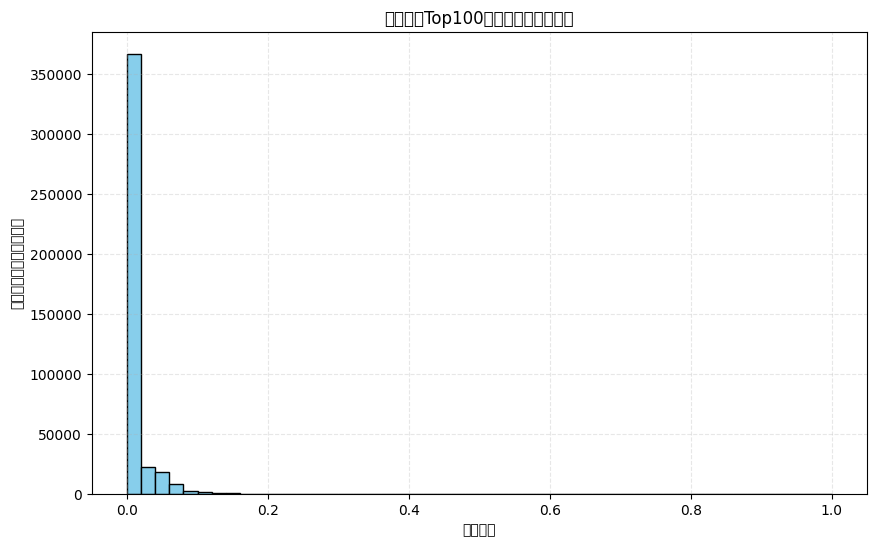

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# bins=50 表示分50个区间，可根据数据调整（如数据集中可增大）
n, bins, patches = plt.hist(flat_sims, bins=50, color='skyblue', edgecolor='black')
plt.title('所有用户Top100相似度的分布直方图', fontsize=12)
plt.xlabel('相似度值', fontsize=10)
plt.ylabel('频数（该区间内的数量）', fontsize=10)
plt.grid(alpha=0.3, linestyle='--')  # 浅色网格线
plt.show()

/home/lgr/anaconda3/envs/llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lgr/anaconda3/envs/llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lgr/anaconda3/envs/llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lgr/anaconda3/envs/llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lgr/anaconda3/envs/llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGR

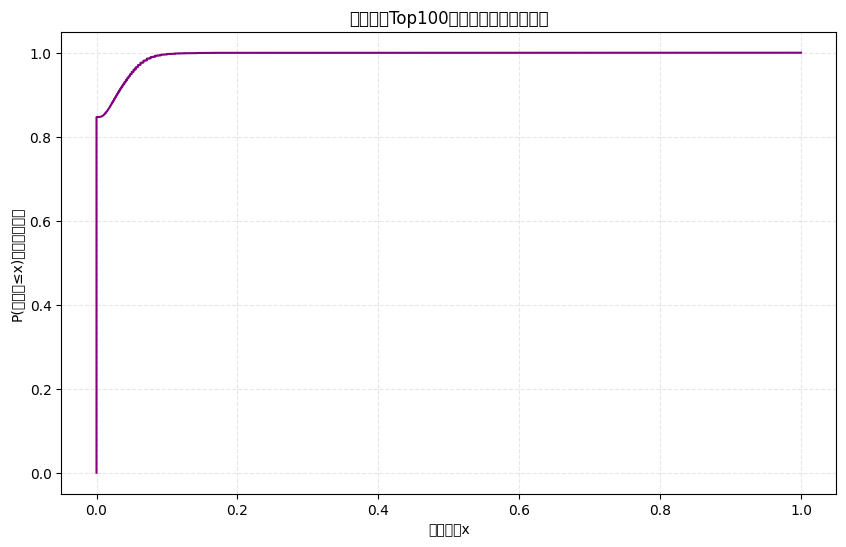

In [17]:
plt.figure(figsize=(10, 6))

# 计算CDF
sorted_sims = np.sort(flat_sims)  # 排序
cdf = np.arange(1, len(sorted_sims) + 1) / len(sorted_sims)  # 累积比例（每个点的比例=位置/总数量）

plt.plot(sorted_sims, cdf, color='purple')
plt.title('所有用户Top100相似度的累积分布函数', fontsize=12)
plt.xlabel('相似度值x', fontsize=10)
plt.ylabel('P(相似度≤x)（累积比例）', fontsize=10)
plt.grid(alpha=0.3, linestyle='--')
plt.show()

In [18]:
## Save llm embedding based similar users
pickle.dump(np.array(sim_scores), open(os.path.join(dataset+"/handled/", f"sim_user_pearson_score_100{mode}_{emb_mode}.pkl"), "wb"))

In [3]:
import pickle
with open(os.path.join(dataset+"/handled/", f"sim_user_pearson_score_100{mode}_{emb_mode}.pkl"), 'rb') as file:
    sim_scores = pickle.load(file)

In [21]:
origin_similar_users[2]

array([ 9924,  2657,  5772, 14924,   455, 10076, 14984, 15687,  8187,
       12715, 10824,  4091, 13182,  1240,  7688,  8332,  8880,  9022,
        1468,  1521, 11197,  9883,  3216, 10815,   967,  2877,  9506,
       11341,  3747, 13582,  4092, 11796,  4941,  4971, 12129,   791,
       11068,  3182,  9580,  6060,  8614, 10780, 10868,  9459, 10098,
        8525, 10794,  7384,  8254,  5398,  8604,    70,   688,  1234,
        9589,  2938,  7051,  2863, 14463, 13228,   489,  1076,  4027,
       14023,  6758,  3789,  8056,  7434,  1700,  1761,  9098,    39,
        2796,   340,  4359, 13334,  9879,  5439,  2155,  9493,   349,
        4634,  9247,  4403,  2030,  9012,  4778,  4146,  7880,   540,
        4139,  9188,  4173,  5668,  6105, 10544,  2379,  4980,   587,
        6843])

In [29]:
merge_indexs = np.concatenate((origin_similar_users[:, :5], final_rank_matrix[:, :5]), axis=1)

In [31]:
pickle.dump(merge_indexs, open(os.path.join(dataset+"/handled/", f"sim_user_100_merge.pkl"), "wb"))

#### 对不同组的用户采用不同的embedding计算相似度

In [131]:
dataset = 'beauty'

In [132]:
import pickle
with open(f'/home/lgr/LLM-ESR/data/{dataset}/handled/sim_user_100.pkl', 'rb') as file:
    origin_similar_users = pickle.load(file)
with open(f'/home/lgr/LLM-ESR/data/{dataset}/handled/sim_user_100_{mode}.pkl', 'rb') as file:
    new_similar_users = pickle.load(file)

In [133]:
origin_similar_users.shape

(52204, 100)

In [134]:
user_popular_dict = {}
with open(f"/home/lgr/LLM-ESR/data/{dataset}/handled/inter_seq.txt",'r') as f:
    lines = f.readlines()
    for line in lines:
        format_line = line.strip().split()
        uid = int(format_line[0]) -1
        iter_len = len(format_line)-1
        user_popular_dict[uid] = iter_len

In [135]:
tail_user_indices = []
head_user_indices = []
for u in user_popular_dict:
    if user_popular_dict[u] < 9:
        tail_user_indices.append(u)
    else:
        head_user_indices.append(u)

In [136]:
tail_sim_users = origin_similar_users[tail_user_indices]
head_sim_users = new_similar_users[head_user_indices]

In [137]:
merged = np.zeros(origin_similar_users.shape, dtype=int)

# 根据索引将提取的元素放回合并后的 ndarray 中
merged[tail_user_indices] = tail_sim_users
merged[head_user_indices] = head_sim_users

In [139]:
pickle.dump(merged, open(os.path.join(dataset+"/handled/", f"sim_user_100_tail_head.pkl"), "wb"))

In [150]:
pickle.load(open(os.path.join(dataset+"/handled/", f"usr_emb_np.pkl"), "rb")).shape

(8556, 1024)

## 分析用户相似度分布

分析 `sim_user_pearson_score_100_qwen_mean_llm.pkl` 文件中所有用户前18个相似用户的相似度分位数


In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据
data_path = "steam/handled/sim_user_pearson_score_100_qwen_mean_llm.pkl"
with open(data_path, "rb") as f:
    sim_data = pickle.load(f)

print(f"数据类型: {type(sim_data)}")
print(f"数据形状: {sim_data.shape if hasattr(sim_data, 'shape') else 'N/A'}")
print(f"数据样例:")
if isinstance(sim_data, np.ndarray):
    print(sim_data[:3])
elif isinstance(sim_data, dict):
    # 显示前3个键值对
    for i, (k, v) in enumerate(list(sim_data.items())[:3]):
        print(f"  {k}: {v}")
else:
    print(sim_data[:3] if hasattr(sim_data, '__getitem__') else sim_data)


In [ ]:
# 提取每个用户前18个相似用户的相似度
# 假设数据是一个字典，键是用户ID，值是[(相似用户ID, 相似度分数), ...]的列表
# 或者是一个矩阵，每行代表一个用户，每列代表相似用户的索引或分数

# 首先判断数据结构
if isinstance(sim_data, dict):
    # 如果是字典结构
    all_top18_scores = []
    for user_id, similar_users in sim_data.items():
        # 获取前18个相似用户
        top18 = similar_users[:18]
        # 提取相似度分数
        if isinstance(top18, list) and len(top18) > 0:
            if isinstance(top18[0], tuple):
                # 格式: [(user_id, score), ...]
                scores = [score for _, score in top18]
            else:
                # 格式: [score, ...]
                scores = top18
            all_top18_scores.extend(scores)
    
    print(f"总共收集了 {len(all_top18_scores)} 个相似度分数")
    
elif isinstance(sim_data, np.ndarray):
    # 如果是numpy数组
    if len(sim_data.shape) == 2:
        # 假设每行是一个用户，前18列是前18个相似用户的分数
        all_top18_scores = sim_data[:, :18].flatten()
        print(f"数据形状: {sim_data.shape}")
        print(f"总共收集了 {len(all_top18_scores)} 个相似度分数")
    else:
        print(f"未知的数组维度: {sim_data.shape}")
        all_top18_scores = []
else:
    print(f"未知的数据类型: {type(sim_data)}")
    all_top18_scores = []

# 转换为numpy数组以便计算
all_top18_scores = np.array(all_top18_scores)
print(f"\n相似度分数统计:")
print(f"  最小值: {np.min(all_top18_scores):.6f}")
print(f"  最大值: {np.max(all_top18_scores):.6f}")
print(f"  平均值: {np.mean(all_top18_scores):.6f}")
print(f"  中位数: {np.median(all_top18_scores):.6f}")


In [ ]:
# 计算分位数
quantiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
quantile_values = np.quantile(all_top18_scores, quantiles)

print("\n前18个相似用户相似度的分位数分析:")
print("=" * 50)
for q, val in zip(quantiles, quantile_values):
    print(f"  {q*100:5.1f}%分位数: {val:.6f}")

# 创建分位数DataFrame以便更好地展示
quantile_df = pd.DataFrame({
    '分位数': [f"{q*100:.1f}%" for q in quantiles],
    '相似度值': quantile_values
})
print("\n分位数表格:")
print(quantile_df.to_string(index=False))


In [ ]:
# 可视化分位数分布
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 直方图
axes[0].hist(all_top18_scores, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('相似度分数', fontsize=12)
axes[0].set_ylabel('频数', fontsize=12)
axes[0].set_title('前18个相似用户相似度分数分布', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 箱线图
axes[1].boxplot(all_top18_scores, vert=True)
axes[1].set_ylabel('相似度分数', fontsize=12)
axes[1].set_title('前18个相似用户相似度箱线图', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n数据总结:")
print(f"  总用户数: {len(sim_data) if isinstance(sim_data, dict) else sim_data.shape[0]}")
print(f"  每个用户取前18个相似用户")
print(f"  总样本数: {len(all_top18_scores)}")


In [ ]:
# 分析每个用户前18个相似用户的平均相似度
if isinstance(sim_data, dict):
    user_avg_scores = []
    for user_id, similar_users in sim_data.items():
        top18 = similar_users[:18]
        if isinstance(top18, list) and len(top18) > 0:
            if isinstance(top18[0], tuple):
                scores = [score for _, score in top18]
            else:
                scores = top18
            user_avg_scores.append(np.mean(scores))
elif isinstance(sim_data, np.ndarray):
    if len(sim_data.shape) == 2:
        user_avg_scores = np.mean(sim_data[:, :18], axis=1)
    else:
        user_avg_scores = []

user_avg_scores = np.array(user_avg_scores)

print("\n每个用户前18个相似用户的平均相似度分布:")
print("=" * 50)
avg_quantiles = [0, 0.25, 0.5, 0.75, 1.0]
avg_quantile_values = np.quantile(user_avg_scores, avg_quantiles)
for q, val in zip(avg_quantiles, avg_quantile_values):
    print(f"  {q*100:5.1f}%分位数: {val:.6f}")

print(f"\n平均相似度统计:")
print(f"  最小值: {np.min(user_avg_scores):.6f}")
print(f"  最大值: {np.max(user_avg_scores):.6f}")
print(f"  平均值: {np.mean(user_avg_scores):.6f}")
print(f"  标准差: {np.std(user_avg_scores):.6f}")


In [ ]:
# 可视化每个用户的平均相似度分布
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(user_avg_scores, bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('平均相似度', fontsize=12)
plt.ylabel('用户数', fontsize=12)
plt.title('每个用户前18个相似用户的平均相似度分布', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(sorted(user_avg_scores), linewidth=2)
plt.xlabel('用户索引（排序后）', fontsize=12)
plt.ylabel('平均相似度', fontsize=12)
plt.title('用户平均相似度累积分布', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
